# Лабораторная работа 3

**Сидимеков Дмитрий**

In [1]:
!pip install -U moabb mne scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.7/837.7 kB 13.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 87.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 99.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.6/254.6 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.4/178.4 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 92.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.8/138.8 kB 10.2 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into a

In [2]:
import moabb.datasets
from moabb.paradigms import P300
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import shutil
import os

def _my_copy_tree(src, dst, symlinks=False):
    # аналог distutils.dir_util.copy_tree по-простому
    if not os.path.exists(dst):
        os.makedirs(dst)

    for item in os.listdir(src):
        s = os.path.join(src, item)
        d = os.path.join(dst, item)
        if os.path.isdir(s):
            _my_copy_tree(s, d, symlinks=symlinks)
        else:
            if not os.path.exists(os.path.dirname(d)):
                os.makedirs(os.path.dirname(d))
            if symlinks and os.path.islink(s):
                linkto = os.readlink(s)
                os.symlink(linkto, d)
            else:
                shutil.copy2(s, d)

# подпишем нашу функцию в модуль shutil
setattr(shutil, "copy_tree", _my_copy_tree)

In [4]:

m_dataset = moabb.datasets.BI2013a(
    NonAdaptive=True,
    Adaptive=True,
    Training=True,
    Online=True,
)
m_dataset

/tmp/ipykernel_1711/3260086925.py:1: DeprecationWarning: Parameter 'NonAdaptive' is deprecated and will be removed in version 2.0. Use 'non_adaptive' instead.
  m_dataset = moabb.datasets.BI2013a(
/tmp/ipykernel_1711/3260086925.py:1: DeprecationWarning: Parameter 'Adaptive' is deprecated and will be removed in version 2.0. Use 'adaptive' instead.
  m_dataset = moabb.datasets.BI2013a(
/tmp/ipykernel_1711/3260086925.py:1: DeprecationWarning: Parameter 'Training' is deprecated and will be removed in version 2.0. Use 'training' instead.
  m_dataset = moabb.datasets.BI2013a(
/tmp/ipykernel_1711/3260086925.py:1: DeprecationWarning: Parameter 'Online' is deprecated and will be removed in version 2.0. Use 'online' instead.
  m_dataset = moabb.datasets.BI2013a(


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
moabb_path = !pip show moabb | grep Location | cut -d " " -f 2
if moabb_path:
    moabb_path = moabb_path[0]
    preprocessing_file = f"{moabb_path}/moabb/datasets/preprocessing.py"

    with open(preprocessing_file, 'r') as f:
        content = f.read()

    if "from sklearn.utils._repr_html.estimator import _VisualBlock" in content:
        content = content.replace(
            "from sklearn.utils._repr_html.estimator import _VisualBlock",
            "# from sklearn.utils._repr_html.estimator import _VisualBlock\n_VisualBlock = None"
        )

        with open(preprocessing_file, 'w') as f:
            f.write(content)
        print("Файл успешно пропатчен")
    else:
        print("Строка не найдена, возможно файл уже пропатчен")

import moabb.datasets as datasets

drive.mount('/content/drive', force_remount=True)
DATA_DIR = "/content/drive/MyDrive/lab3_eeg"
os.makedirs(DATA_DIR, exist_ok=True)
print("Рабочая папка для данных:", DATA_DIR)

dataset = datasets.BI2013a()
paradigm = P300()
all_subjects = range(1, 2)

Xs = []
ys = []
loaded_subjects = []

for subj in all_subjects:
    X_file = os.path.join(DATA_DIR, f"X_subject{subj}.npy")
    y_file = os.path.join(DATA_DIR, f"y_subject{subj}.npy")
    if os.path.exists(X_file) and os.path.exists(y_file):
        print(f"Субъект {subj} уже сохранён, загружаем с диска...")
        X_subj = np.load(X_file)
        y_subj = np.load(y_file)
    else:
        print(f"Скачиваем и обрабатываем субъект {subj}...")
        X_subj, y_subj, _ = paradigm.get_data(dataset, subjects=[subj])
        np.save(X_file, X_subj)
        np.save(y_file, y_subj)
        print(f"Субъект {subj} сохранён на диск.")

    Xs.append(X_subj)
    ys.append(y_subj)
    loaded_subjects.append(subj)

X = np.concatenate(Xs, axis=0)
y = np.concatenate(ys, axis=0)

Mounted at /content/drive
Рабочая папка для данных: /content/drive/MyDrive/lab3_eeg
Субъект 1 уже сохранён, загружаем с диска...


In [7]:
m_dataset = moabb.datasets.BI2013a(
    NonAdaptive=True,
    Adaptive=False,
    Training=True,
    Online=False,
)

paradigm = P300(
    resample = 128,
    tmin=0.2,
    tmax=0.8
)

subjects = m_dataset.subject_list[0:1]

X, y, meta = paradigm.get_data(
    dataset=m_dataset,
    subjects=subjects
)

Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)


/tmp/ipykernel_1711/1621224262.py:1: DeprecationWarning: Parameter 'NonAdaptive' is deprecated and will be removed in version 2.0. Use 'non_adaptive' instead.
  m_dataset = moabb.datasets.BI2013a(
/tmp/ipykernel_1711/1621224262.py:1: DeprecationWarning: Parameter 'Adaptive' is deprecated and will be removed in version 2.0. Use 'adaptive' instead.
  m_dataset = moabb.datasets.BI2013a(
/tmp/ipykernel_1711/1621224262.py:1: DeprecationWarning: Parameter 'Training' is deprecated and will be removed in version 2.0. Use 'training' instead.
  m_dataset = moabb.datasets.BI2013a(
/tmp/ipykernel_1711/1621224262.py:1: DeprecationWarning: Parameter 'Online' is deprecated and will be removed in version 2.0. Use 'online' instead.
  m_dataset = moabb.datasets.BI2013a(
/usr/local/lib/python3.12/dist-packages/moabb/datasets/download.py:97: RuntimeWarning: Setting non-standard config type: "MNE_DATASETS_BRAININVADERS2013_PATH"
  set_config(key, get_config("MNE_DATA"))
/usr/local/lib/python3.12/dist-packa

  0%|                                               | 0.00/265M [00:00<?, ?B/s]

SHA256 hash of downloaded file: 8c0c9cb3e3345247430d5945e91c645bffa4074f79a196ac911aefde67a0acc1
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'zenodo.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'zenodo.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  0%|                                               | 0.00/244M [00:00<?, ?B/s]

...

SHA256 hash of downloaded file: 749b9d31e00eb0aaf812fe1cb8f473ac94d36f2ae44bc67cb4207b5278e92130
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'zenodo.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'zenodo.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  0%|                                               | 0.00/130M [00:00<?, ?B/s]

SHA256 hash of downloaded file: f99bba6152cddb1f84ad302435fb77dd4b53fc091968020fce34ccf7bba84749
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'zenodo.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'zenodo.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  0%|                                               | 0.00/114M [00:00<?, ?B/s]

SHA256 hash of downloaded file: acc6ba020e0dd6cb59032b88befbbd3a0fa8b6bae2d9f7cb3c6e048139614246
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


In [8]:
print("X shape:", X.shape)
print("Количество эпох:", X.shape[0])
print("Количество каналов:", X.shape[1])
print("Количество временных отсчётов:", X.shape[2])
print("Классы:", np.unique(y, return_counts=True))
print("Доля Target:", np.mean(y == "Target"))
print("Доля NonTarget:", np.mean(y == "NonTarget"))

X shape: (3840, 16, 77)
Количество эпох: 3840
Количество каналов: 16
Количество временных отсчётов: 77
Классы: (array(['NonTarget', 'Target'], dtype='<U9'), array([3200,  640]))
Доля Target: 0.16666666666666666
Доля NonTarget: 0.8333333333333334


In [9]:
print(X.shape)        # (N_trials, N_channels, N_samples)
print(y.shape)        # (N_trials,)
# print(meta.head())
print(set(y))         # посмотреть уникальные метки

(3840, 16, 77)
(3840,)
{np.str_('NonTarget'), np.str_('Target')}


### Предобработка данных

In [10]:
y_num = np.where(y == "Target", 1, -1)
y_num = np.where(y == "Target", 1, -1)
n, ch, ts = X.shape
X_flat = X.reshape(n, ch * ts)

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_flat, y_num, test_size=0.2, random_state=42, stratify=y_num
)

In [12]:
(y_num>0).sum() / y_num.shape[0]

np.float64(0.16666666666666666)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

## Модель SVM

In [14]:
def binary_accuracy_score(y_true, y_pred):
    return float(np.mean(y_true == y_pred))

def precision_recall_f1(y_true, y_pred):
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return precision, recall, f1

In [15]:
class SVMClassifier:
    def __init__(self, lr=1e-3, C=0.1, epochs=100, batch_size=64, print_every=25) -> None:
        self.C = C
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.print_every = print_every
        self.w = None
        self.b = None
        self.hist_w = None
        self.hist = {}

    def _init_params(self, n_features):
        self.hist_w = []
        self.hist = {
            "tr_loss": [],
            "tr_acc": [],
            "tr_precision": [],
            "tr_recall": [],
            "tr_f1": [],
            "val_loss": [],
            "val_acc": [],
            "val_precision": [],
            "val_recall": [],
            "val_f1": [],
        }
        self.w = np.zeros(n_features, dtype=float)
        self.b = 0.0

    def fit(
        self,
        X_train: np.ndarray,
        y_train: np.ndarray,
        X_val: np.ndarray,
        y_val: np.ndarray,
    ):
        _, n_features = X_train.shape
        self._init_params(n_features)

        X_train = np.asarray(X_train, dtype=float)
        X_val = np.asarray(X_val, dtype=float)
        y_train = np.asarray(y_train, dtype=float)
        y_val = np.asarray(y_val, dtype=float)

        N_train, _ = X_train.shape
        N_val, _ = X_val.shape

        for epoch in range(self.epochs):
            idx_rnd_tr = np.random.permutation(N_train)
            tr_loss, tr_acc, tr_precision, tr_recall, tr_f1 = 0.0, 0.0, 0.0, 0.0, 0.0
            val_loss, val_acc, val_precision, val_recall, val_f1 = 0.0, 0.0, 0.0, 0.0, 0.0

            # train
            for start in range(0, N_train, self.batch_size):
                end = min(N_train, start + self.batch_size)
                idx = idx_rnd_tr[start:end]

                X_batch_tr = X_train[idx]
                y_batch_tr = y_train[idx]

                acc, precision, recall, f1, loss = self._step(X_batch_tr, y_batch_tr)
                tr_loss += float(loss)
                tr_acc += acc
                tr_precision += precision
                tr_recall += recall
                tr_f1 += f1

            idx_rnd_val = np.random.permutation(N_val)

            # val
            for start in range(0, N_val, self.batch_size):
                end = min(N_val, start + self.batch_size)
                idx = idx_rnd_val[start:end]

                X_batch_val = X_val[idx]
                y_batch_val = y_val[idx]

                acc, precision, recall, f1, loss = self._val_metrics(X_batch_val, y_batch_val)
                val_loss += float(loss)
                val_acc += acc
                val_precision += precision
                val_recall += recall
                val_f1 += f1

            n_tr_batches = (N_train + self.batch_size - 1) // self.batch_size
            n_val_batches = (N_val + self.batch_size - 1) // self.batch_size

            self.hist["tr_loss"].append(tr_loss / n_tr_batches)
            self.hist["tr_acc"].append(tr_acc / n_tr_batches)
            self.hist["tr_precision"].append(tr_precision / n_tr_batches)
            self.hist["tr_recall"].append(tr_recall / n_tr_batches)
            self.hist["tr_f1"].append(tr_f1 / n_tr_batches)
            self.hist["val_loss"].append(val_loss / n_val_batches)
            self.hist["val_acc"].append(val_acc / n_val_batches)
            self.hist["val_precision"].append(val_precision / n_val_batches)
            self.hist["val_recall"].append(val_recall / n_val_batches)
            self.hist["val_f1"].append(val_f1 / n_val_batches)

            if (epoch + 1) % self.print_every == 0:
                print(
                    f"EPOCH {epoch + 1}:\n"
                    f"Train - Loss: {tr_loss/n_tr_batches:.3f}, Acc: {tr_acc/n_tr_batches:.3f}, Precision: {tr_precision/n_tr_batches:.3f}, Recall: {tr_recall/n_tr_batches:.3f}, F1: {tr_f1/n_tr_batches:.3f}\n"
                    f"Val   - Loss: {val_loss/n_val_batches:.3f}, Acc: {val_acc/n_val_batches:.3f}, Precision: {val_precision/n_val_batches:.3f}, Recall: {val_recall/n_val_batches:.3f}, F1: {val_f1/n_val_batches:.3f}\n"
                )

    def _step(self, X_batch: np.ndarray, y_batch: np.ndarray):
        scores = X_batch @ self.w + self.b
        preds = np.sign(scores)
        margin = y_batch * (scores)
        xi = 1.0 - margin
        mask = (xi > 0).astype(float)

        pos_mask = (y_batch > 0).astype(float)
        neg_mask = (y_batch < 0).astype(float)

        n_pos = max(pos_mask.sum(), 1.0)
        n_neg = max(neg_mask.sum(), 1.0)

        # вес положительного класса больше (его около 16% только)
        w_pos = n_neg / (n_pos + n_neg)
        w_neg = n_pos / (n_pos + n_neg)

        sample_weight = w_pos * pos_mask + w_neg * neg_mask

        hinge = np.clip(xi, 0.0, None) * sample_weight

        L = 0.5 * np.sum(self.w * self.w) + self.C * hinge.mean()

        N = X_batch.shape[0]

        y_sv = y_batch * mask * sample_weight

        dLdw = self.w - self.C * (X_batch.T @ y_sv) / N
        dLdb = -self.C * y_sv.mean()

        self.w -= self.lr * dLdw
        self.b -= self.lr * dLdb

        acc, precision, recall, f1 = self._compute_metrics(y_batch, preds)
        return acc, precision, recall, f1, L

    def _val_metrics(self, X_batch, y_batch):
        scores = X_batch @ self.w + self.b
        preds = np.sign(scores)
        margin = y_batch * (scores)
        xi = 1.0 - margin

        hinge = np.clip(xi, 0.0, None)

        L = 0.5 * np.sum(self.w * self.w) + self.C * hinge.mean()

        # pos_rate = (preds > 0).mean()
        # print("Val positive prediction rate:", pos_rate)


        acc, precision, recall, f1 = self._compute_metrics(y_batch, preds)
        return acc, precision, recall, f1, L

    def _compute_metrics(self, y_batch, preds):
        # -1,1 в 0,1
        y_true_bin = (y_batch > 0).astype(int)
        y_pred_bin = (preds > 0).astype(int)

        acc = binary_accuracy_score(y_true_bin, y_pred_bin)
        precision, recall, f1 = precision_recall_f1(y_true_bin, y_pred_bin)

        return acc, precision, recall, f1
    
    def predict_scores(self, X):
        X = np.asarray(X, dtype=float)
        return X @ self.w + self.b

    def predict(self, X):
        y_score = self.predict_scores(X)
        y_pred = np.where(y_score >= 0, 1.0, -1.0)
        return y_pred

    def plot_metrics(self, figsize=(15, 10)):
        epochs = range(1, len(self.hist['tr_loss']) + 1)

        fig, axes = plt.subplots(2, 3, figsize=figsize)
        fig.suptitle('SVM Classifier metrics', fontsize=16, fontweight='bold')

        # Loss
        axes[0, 0].plot(epochs, self.hist['tr_loss'], 'b-', label='Train Loss', linewidth=2)
        axes[0, 0].plot(epochs, self.hist['val_loss'], 'r-', label='Val Loss', linewidth=2)
        axes[0, 0].set_title('Loss')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        # Accuracy
        axes[0, 1].plot(epochs, self.hist['tr_acc'], 'b-', label='Train Accuracy', linewidth=2)
        axes[0, 1].plot(epochs, self.hist['val_acc'], 'r-', label='Val Accuracy', linewidth=2)
        axes[0, 1].set_title('Accuracy')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Accuracy')
        axes[0, 1].set_ylim(0, 1)
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)

        # F1
        axes[0, 2].plot(epochs, self.hist['tr_f1'], 'b-', label='Train F1-Score', linewidth=2)
        axes[0, 2].plot(epochs, self.hist['val_f1'], 'r-', label='Val F1-Score', linewidth=2)
        axes[0, 2].set_title('F1-Score')
        axes[0, 2].set_xlabel('Epoch')
        axes[0, 2].set_ylabel('F1-Score')
        axes[0, 2].set_ylim(0, 1)
        axes[0, 2].legend()
        axes[0, 2].grid(True, alpha=0.3)

        # Error rate (1 - accuracy)
        tr_error = [1 - acc for acc in self.hist['tr_acc']]
        val_error = [1 - acc for acc in self.hist['val_acc']]

        axes[1, 0].plot(epochs, tr_error, 'b-', label='Train Error', linewidth=2)
        axes[1, 0].plot(epochs, val_error, 'r-', label='Val Error', linewidth=2)
        axes[1, 0].set_title('Error Rate (1 - Accuracy)')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Error Rate')
        axes[1, 0].set_ylim(0, 1)
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)

        # Loss vs Accuracy (двойная ось Y)
        ax2 = axes[1, 1].twinx()
        line1 = axes[1, 1].plot(epochs, self.hist['tr_loss'], 'b-', label='Train Loss', linewidth=2)
        line2 = ax2.plot(epochs, self.hist['tr_acc'], 'b--', label='Train Accuracy', linewidth=2)
        line3 = axes[1, 1].plot(epochs, self.hist['val_loss'], 'r-', label='Val Loss', linewidth=2)
        line4 = ax2.plot(epochs, self.hist['val_acc'], 'r--', label='Val Accuracy', linewidth=2)

        axes[1, 1].set_title('Loss vs Accuracy')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Loss')
        ax2.set_ylabel('Accuracy')
        ax2.set_ylim(0, 1)

        lines = line1 + line2 + line3 + line4
        labels = [l.get_label() for l in lines]
        axes[1, 1].legend(lines, labels, loc='center right')
        axes[1, 1].grid(True, alpha=0.3)

        axes[1, 2].axis('off')

        best_val_acc = max(self.hist['val_acc'])
        best_val_f1 = max(self.hist['val_f1'])
        best_epoch = np.argmax(self.hist['val_f1']) + 1
        best_val_precision = max(self.hist['val_precision'])
        best_val_recall = max(self.hist['val_recall'])

        axes[1, 2].text(0.1, 0.7, f'Best Validation:\n\nAccuracy: {best_val_acc:.3f}\nPrecision: {best_val_precision:.3f}\nRecall: {best_val_recall:.3f}\nF1-Score: {best_val_f1:.3f}\nEpoch: {best_epoch}',
                       fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))

        plt.tight_layout()
        plt.show()


    def get_best_metrics(self):
        best_val_acc = max(self.hist['val_acc'])
        best_val_f1 = max(self.hist['val_f1'])
        best_epoch = np.argmax(self.hist['val_f1']) + 1
        best_val_precision = max(self.hist['val_precision'])
        best_val_recall = max(self.hist['val_recall'])

        return {
            'best_accuracy': best_val_acc,
            'best_precision': best_val_precision,
            'best_recall': best_val_recall,
            'best_f1_score': best_val_f1,
            'best_epoch': best_epoch
        }

## Обучение и метрики

EPOCH 50:
Train - Loss: 0.775, Acc: 0.898, Precision: 0.627, Recall: 0.951, F1: 0.753
Val   - Loss: 3.241, Acc: 0.893, Precision: 0.627, Recall: 0.899, F1: 0.737

EPOCH 100:
Train - Loss: 0.764, Acc: 0.916, Precision: 0.684, Recall: 0.935, F1: 0.787
Val   - Loss: 2.821, Acc: 0.906, Precision: 0.663, Recall: 0.874, F1: 0.754

EPOCH 150:
Train - Loss: 0.757, Acc: 0.917, Precision: 0.687, Recall: 0.932, F1: 0.790
Val   - Loss: 2.728, Acc: 0.909, Precision: 0.681, Recall: 0.851, F1: 0.756

EPOCH 200:
Train - Loss: 0.748, Acc: 0.925, Precision: 0.711, Recall: 0.930, F1: 0.804
Val   - Loss: 2.705, Acc: 0.904, Precision: 0.665, Recall: 0.860, F1: 0.750

EPOCH 250:
Train - Loss: 0.750, Acc: 0.924, Precision: 0.704, Recall: 0.935, F1: 0.802
Val   - Loss: 2.716, Acc: 0.901, Precision: 0.665, Recall: 0.827, F1: 0.736

EPOCH 300:
Train - Loss: 0.752, Acc: 0.926, Precision: 0.712, Recall: 0.930, F1: 0.806
Val   - Loss: 2.707, Acc: 0.906, Precision: 0.679, Recall: 0.836, F1: 0.749

EPOCH 350:
Train 

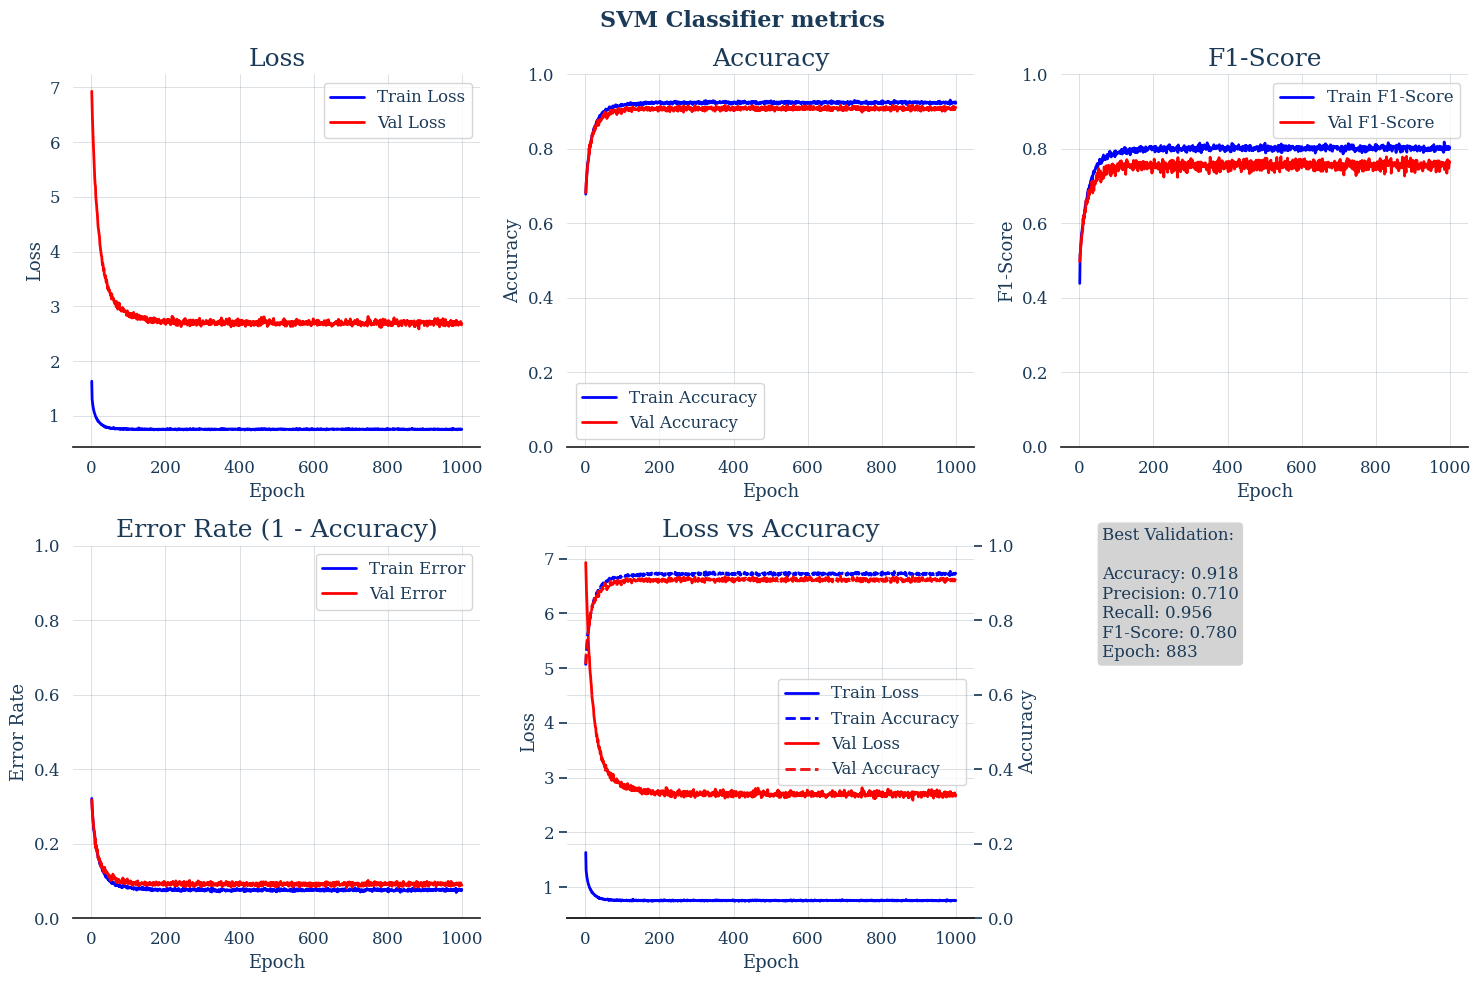

{'best_accuracy': 0.91796875, 'best_precision': 0.7102645502645504, 'best_recall': 0.9555555555555556, 'best_f1_score': 0.7798820564778012, 'best_epoch': np.int64(883)}


In [16]:
X_tr_t = X_train
y_tr_t = y_train

X_val_t = X_val
y_val_t = y_val

svm = SVMClassifier(C=10, lr=3e-3, epochs=1000, batch_size=256, print_every=50)
svm.fit(X_tr_t, y_tr_t, X_val_t, y_val_t)

svm.plot_metrics()
print(svm.get_best_metrics())

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

y_val_scores = svm.predict_scores(X_val_t)
y_val_pred = svm.predict(X_val_t)

y_val_true_bin = (y_val == 1).astype(int)
y_val_pred_bin = (y_val_pred == 1).astype(int)

print("Accuracy:", accuracy_score(y_val_true_bin, y_val_pred_bin))
print("Precision:", precision_score(y_val_true_bin, y_val_pred_bin))
print("Recall:", recall_score(y_val_true_bin, y_val_pred_bin))
print("F1:", f1_score(y_val_true_bin, y_val_pred_bin))

print(classification_report(y_val_true_bin, y_val_pred_bin, target_names=["NonTarget", "Target"]))

Accuracy: 0.9114583333333334
Precision: 0.6851851851851852
Recall: 0.8671875
F1: 0.7655172413793103
              precision    recall  f1-score   support

   NonTarget       0.97      0.92      0.95       640
      Target       0.69      0.87      0.77       128

    accuracy                           0.91       768
   macro avg       0.83      0.89      0.86       768
weighted avg       0.92      0.91      0.92       768



### **ROC кривая**

In [18]:
def roc_curve(y_true, y_scores):
    idx_sorted = np.argsort(y_scores)[::-1]
    print(y_true[:5])
    print(y_scores[:5])
    y_true = y_true[idx_sorted]
    y_scores = y_scores[idx_sorted]
    n = len(y_scores)

    # print(y_true, y_scores)

    tprs = []
    fprs = []

    # -1: y_score <= t
    # 1: y_score > t
    # t: inf, (y_score[0] + y_score[1]) / 2, ..., y_score[-1] == min(y_scores)
    for i in range(n + 1):
        if i == 0:
            t = np.inf
        elif i == n:
            t = -np.inf
        else:
            t = (y_scores[i - 1] + y_scores[i]) / 2

        # print(t)
        # t = 10.0
        # y_score = 9.0: y_pred = -1
        # y_score = 11.0: y_pred = 1
        y_pred = np.where(y_scores <= t, -1, 1)

        tp = np.sum((y_pred == 1) & (y_true == 1))
        tn = np.sum((y_pred == -1) & (y_true == -1))
        fn = np.sum((y_pred == -1) & (y_true == 1))
        fp = np.sum((y_pred == 1) & (y_true == -1))

        tpr = tp / (tp + fn + 1e-10)
        fpr = fp / (fp + tn + 1e-10)

        # print(tpr, fpr)

        tprs.append(tpr)
        fprs.append(fpr)

    # print(tprs, fprs)
    plt.xlim(0.0, 1.0)
    plt.ylim(0.0, 1.0)
    plt.xlabel('fpr')
    plt.ylabel('tpr')
    plt.title("ROC curve for SVM")
    plt.plot(fprs, tprs)
    plt.show()

    order = np.argsort(fprs)
    fpr_sorted = np.array(fprs)[order]
    tpr_sorted = np.array(tprs)[order]

    auc = np.trapezoid(tpr_sorted, fpr_sorted)

    return auc


[-1 -1 -1  1 -1]
[-0.69799106 -1.40623415 -1.88144991  0.35047037  0.1520162 ]


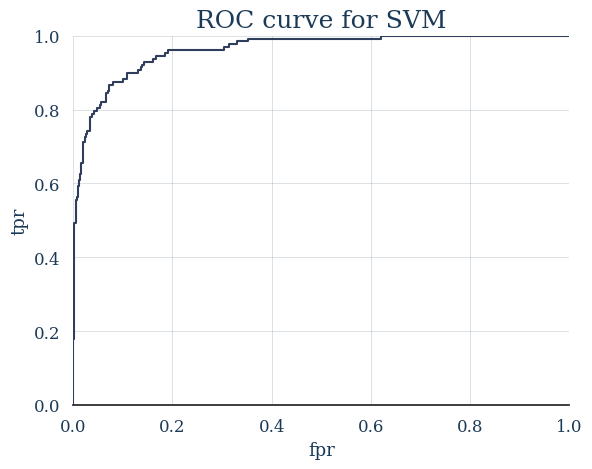

ROC-AUC = 0.962


In [19]:
auc = roc_curve(y_val, y_val_scores)
print(f"ROC-AUC = {auc:.3f}")